In [1]:
# Ejecuta esta celda para instalar todas las librerías necesarias
!pip install tensorflow pillow matplotlib scipy

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense,Dropout
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from pathlib import Path
from tensorflow.keras.callbacks import EarlyStopping

In [11]:
# === Parameters ===
IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 32
NUM_TRAINABLE_LAYERS = 0 # Change this to >0 when you want to fine-tune
BASE_DIR = Path.cwd()
# === Directories ===
TRAIN_DATA_DIR = BASE_DIR / "Fish_Dataset_Splitted" / "train"
VALIDATION_DATA_DIR = BASE_DIR / "Fish_Dataset_Splitted" / "validation"
TEST_DATA_DIR = BASE_DIR / "Fish_Dataset_Splitted" / "test"


# === Data Generators ===
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input,
rotation_range=20,
width_shift_range=0.2,
height_shift_range=0.2,
zoom_range=0.2,
horizontal_flip=True)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
TRAIN_DATA_DIR,
target_size=(IMG_WIDTH, IMG_HEIGHT),
batch_size=BATCH_SIZE,
class_mode="sparse",
shuffle=True
)

validation_generator = val_test_datagen.flow_from_directory(
VALIDATION_DATA_DIR,
target_size=(IMG_WIDTH, IMG_HEIGHT),
batch_size=BATCH_SIZE,
class_mode="sparse",
shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
TEST_DATA_DIR,
target_size=(IMG_WIDTH, IMG_HEIGHT),
batch_size=BATCH_SIZE,
class_mode="sparse",
shuffle=False)

# === Load and Configure MobileNetV2 ===
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_WIDTH, IMG_HEIGHT, 3))

# Freeze all layers first
for layer in base_model.layers:
  layer.trainable = False

# Unfreeze last N layers
if NUM_TRAINABLE_LAYERS > 0:
  for layer in base_model.layers[-NUM_TRAINABLE_LAYERS:]:
    layer.trainable = True

base_model.summary()


Found 4000 images belonging to 5 classes.
Found 500 images belonging to 5 classes.
Found 500 images belonging to 5 classes.


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:

# === Build the Model ===
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(train_generator.num_classes, activation="softmax")
])

# === Compile ===
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
#EarlyStopping
es = EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=5,
    restore_best_weights=True
)
# === Train ===
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50,
    callbacks=[es]
)



Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 109s 841ms/step - accuracy: 0.8320 - loss: 0.5301 - val_accuracy: 0.9820 - val_loss: 0.1143
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 98s 781ms/step - accuracy: 0.9772 - loss: 0.1071 - val_accuracy: 0.9900 - val_loss: 0.0472
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 98s 783ms/step - accuracy: 0.9845 - loss: 0.0668 - val_accuracy: 0.9960 - val_loss: 0.0346
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 95s 762ms/step - accuracy: 0.9912 - loss: 0.0415 - val_accuracy: 0.9960 - val_loss: 0.0278
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 90s 720ms/step - accuracy: 0.9933 - loss: 0.0348 - val_accuracy: 0.9940 - val_loss: 0.0195
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 90s 722ms/step - accuracy: 0.9923 - loss: 0.0294 - val_accuracy: 0.9940 - val_loss: 0.0160
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 92s 737ms/step - accuracy: 0.9950 - loss: 0.0237 - val_accuracy: 0.9960 - val_loss: 0.0142
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 88s 707ms/step - accuracy: 0.9960 - loss: 

In [8]:
model.save("modelo_peces_MobileNetV2.keras")
print("¡Modelo guardado con éxito en el disco!")

¡Modelo guardado con éxito en el disco!


¡Modelo cargado desde el disco con éxito!
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 441ms/step - accuracy: 1.0000 - loss: 0.0213
Test Accuracy (del modelo cargado): 1.0000


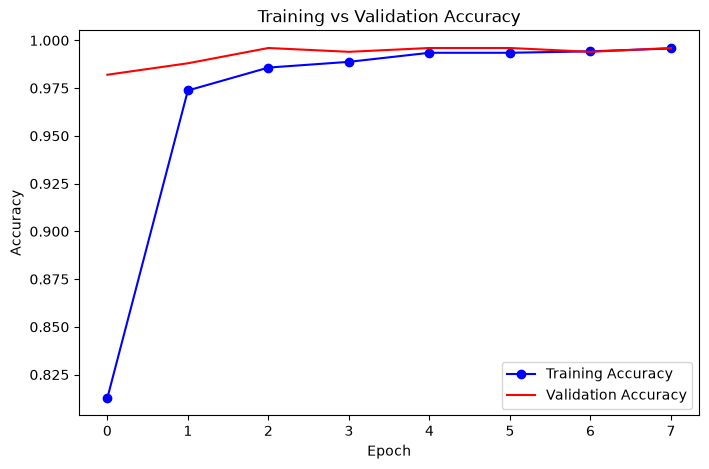

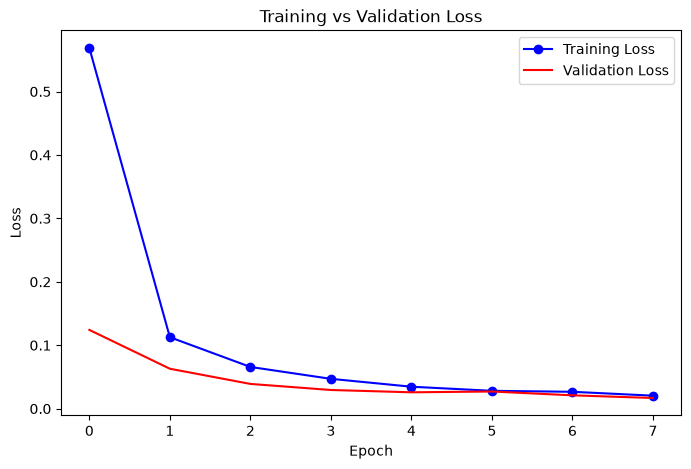

In [9]:
ruta_guardado = r"C:\IA-FAC\modelo_peces_MobileNetV2.keras"

# 2. Cargamos exactamente el archivo que acabamos de guardar
modelo_cargado = load_model(ruta_guardado)
print("¡Modelo cargado desde el disco con éxito!")
# === Evaluar sin pisar el historial ===
# Cambiamos los nombres a 'test_loss' y 'test_acc' para proteger las listas del historial
test_loss, test_acc = modelo_cargado.evaluate(test_generator)
print(f"Test Accuracy (del modelo cargado): {test_acc:.4f}")

# === Extraer historiales originales ===
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(len(accuracy))

# === Gráfica 1: Accuracy ===
plt.figure(figsize=(8,5))
plt.plot(epochs, accuracy, "bo-", label="Training Accuracy")
plt.plot(epochs, val_accuracy, "r-", label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# === Gráfica 2: Loss ===
plt.figure(figsize=(8,5))
plt.plot(epochs, loss, "bo-", label="Training Loss")
plt.plot(epochs, val_loss, "r-", label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()